In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def get_hex_color(value, min_val, max_val, alpha=0.3):
    """Maps a value to a hex color between Red (low) and Green (high)."""
    if pd.isna(value) or min_val == max_val: return "FFFFFF"
    norm = (value - min_val) / (max_val - min_val)
    cmap = plt.get_cmap('RdYlGn')
    rgb = np.array(cmap(norm)[:3]) 
    
    # Blend with white: result = color * alpha + white * (1 - alpha)
    white = np.array([1.0, 1.0, 1.0])
    light_rgb = rgb * alpha + white * (1 - alpha)
    
    return mcolors.to_hex(light_rgb).replace('#', '').upper()

def format_cell(val, sd, is_bold=False):
    """Formats the cell content; returns '-' if value is missing."""
    if pd.isna(val) or val == "" or val == "-":
        return "-"
    
    # Ensure val and sd are floats for formatting
    try:
        f_val, f_sd = float(val), float(sd)
        text = f"${f_val:.2f}_{{{f'{f_sd:.2f}'.lstrip('0')}}}$"
        return f"\\textbf{{{text}}}" if is_bold else text
    except (ValueError, TypeError):
        return "-"

def generate_latex_table(csv_path):
    df = pd.read_csv(csv_path)
    
    models = [
        "MLP", "LogReg", "XGBoost", "HyperFast", "MotherNet", 
        "TabDistill+PFN", "TabDistill+T0pp", "SAINT", "TabPFN", "TabLLM", "TabICL"
    ]
    
    latex_lines = []
    datasets = df[df['Dataset'] != 'Avg.']['Dataset'].unique()
    
    for ds in datasets:
        sub = df[df['Dataset'] == ds]
        for i, (idx, row) in enumerate(sub.iterrows()):
            line_parts = []
            line_parts.append(f"\\multirow{{{len(sub)}}}{{*}}{{{ds}}}" if i == 0 else "")
            line_parts.append(f"{int(row['Shots'])}")
            
            for m in models:
                line_parts.append(format_cell(row[m], row.get(f"{m}_SD", 0), m == "TabICL"))
            
            latex_lines.append(" & ".join(line_parts) + " \\\\")
        latex_lines.append("\\midrule")

    # Average rows with Heatmap and empty value handling
    avg_df = df[df['Dataset'] == 'Avg.']
    for i, (idx, row) in enumerate(avg_df.iterrows()):
        line_parts = []
        line_parts.append(f"\\multirow{{{len(avg_df)}}}{{*}}{{\\textbf{{Avg.}}}}" if i == 0 else "")
        line_parts.append(f"{int(row['Shots'])}")
        
        # Calculate min/max only for valid numbers in the row
        row_numeric = pd.to_numeric(row[models], errors='coerce').dropna()
        min_v, max_v = (row_numeric.min(), row_numeric.max()) if not row_numeric.empty else (0, 0)
        
        for m in models:
            val = row[m]
            sd = row.get(f"{m}_SD", 0)
            
            content = format_cell(val, sd, m == "TabICL")
            
            if content == "-":
                line_parts.append("-")
            else:
                color = get_hex_color(float(val), min_v, max_v)
                line_parts.append(f"\\cellcolor[HTML]{{{color}}}{content}")
        
        latex_lines.append(" & ".join(line_parts) + " \\\\")

    return "\n".join(latex_lines)

In [13]:
print(generate_latex_table("./all_results.csv"))

\multirow{3}{*}{Bank} & 4 & $0.57_{.08}$ & $0.54_{.10}$ & $0.50_{.00}$ & $0.48_{.02}$ & $0.54_{.06}$ & $0.53_{.11}$ & $0.72_{.01}$ & $0.70_{.02}$ & $0.61_{.12}$ & $0.59_{.10}$ & \textbf{$0.62_{.07}$} \\
 & 8 & $0.61_{.11}$ & $0.65_{.06}$ & $0.56_{.10}$ & $0.69_{.02}$ & $0.48_{.03}$ & $0.62_{.07}$ & $0.67_{.06}$ & $0.67_{.02}$ & $0.69_{.07}$ & $0.64_{.05}$ & \textbf{$0.69_{.11}$} \\
 & 16 & $0.72_{.05}$ & $0.72_{.03}$ & $0.72_{.08}$ & $0.77_{.02}$ & $0.46_{.04}$ & $0.72_{.04}$ & $0.68_{.02}$ & $0.72_{.01}$ & $0.74_{.02}$ & $0.65_{.05}$ & \textbf{$0.74_{.08}$} \\
\midrule
\multirow{3}{*}{Blood} & 4 & $0.57_{.10}$ & $0.60_{.16}$ & $0.50_{.00}$ & $0.58_{.04}$ & $0.60_{.05}$ & $0.60_{.08}$ & $0.56_{.07}$ & $0.62_{.08}$ & $0.60_{.07}$ & $0.58_{.09}$ & \textbf{$0.55_{.04}$} \\
 & 8 & $0.61_{.09}$ & $0.66_{.12}$ & $0.55_{.09}$ & $0.64_{.02}$ & $0.62_{.06}$ & $0.61_{.08}$ & $0.67_{.05}$ & $0.58_{.08}$ & $0.62_{.06}$ & $0.66_{.03}$ & \textbf{$0.54_{.07}$} \\
 & 16 & $0.60_{.09}$ & $0.63_{.11}$ &

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def get_hex_color(value, min_val, max_val, alpha=0.25):
    """Maps value to a light pastel color."""
    if pd.isna(value) or min_val == max_val: 
        return "FFFFFF"
    norm = (value - min_val) / (max_val - min_val)
    cmap = plt.get_cmap('RdYlGn')
    rgb = np.array(cmap(norm)[:3]) 
    white = np.array([1.0, 1.0, 1.0])
    light_rgb = rgb * alpha + white * (1 - alpha)
    return mcolors.to_hex(light_rgb).replace('#', '').upper()

def format_cell(val, sd, is_best=False):
    """Formats cell as $AUC_{SD}$ with math-mode bolding."""
    if pd.isna(val) or val == "" or val == "-":
        return "-"
    try:
        f_val, f_sd = float(val), float(sd)
        content = f"{f_val:.2f}_{{{f_sd:.2f}}}"
        # Using \mathbf inside math mode to bold numbers for ICML
        if is_best:
            return f"$\\mathbf{{{content}}}$"
        return f"${content}$"
    except (ValueError, TypeError):
        return "-"

def generate_latex_table(csv_path):
    df = pd.read_csv(csv_path)
    
    # Full list of models in display order
    models = ["MLP", "LogReg", "XGBoost", "HyperFast", "MotherNet", 
              "TabDistill+PFN", "TabDistill+T0pp", "SAINT", "TabPFN", "TabLLM", "TabICL"]
    
    # Subset of the first 7 models for competitive bolding
    bold_candidates = models[:7]
    
    latex_lines = []
    datasets = df['Dataset'].unique()
    
    for ds in datasets:
        sub = df[df['Dataset'] == ds]
        is_avg = (ds == 'Avg.')
        
        for i, (idx, row) in enumerate(sub.iterrows()):
            # Calculate max only for the first 7 columns
            row_numeric = pd.to_numeric(row[bold_candidates], errors='coerce').dropna()
            row_max = row_numeric.max() if not row_numeric.empty else None
            
            # Setup row headers
            label = f"\\textbf{{Average}}" if is_avg else ds
            line = [f"\\multirow{{{len(sub)}}}{{*}}{{{label}}}" if i == 0 else "", f"{int(row['Shots'])}"]
            
            for m in models:
                val = row[m]
                # Bold only if it's in the first 7 AND is the max of those 7
                is_best = (m in bold_candidates and val == row_max and val is not None)
                content = format_cell(val, row.get(f"{m}_SD", 0), is_best=is_best)
                
                if is_avg and content != "-":
                    # Color logic still uses all models for the heatmap gradient
                    all_numeric = pd.to_numeric(row[models], errors='coerce').dropna()
                    color = get_hex_color(float(val), all_numeric.min(), all_numeric.max())
                    line.append(f"\\cellcolor[HTML]{{{color}}}{content}")
                else:
                    line.append(content)
            
            latex_lines.append(" & ".join(line) + " \\\\")
            
        if not is_avg:
            latex_lines.append("\\midrule")

    return "\n".join(latex_lines)

In [2]:
print(generate_latex_table("./all_results.csv"))

\multirow{3}{*}{Bank} & 4 & $0.57_{0.08}$ & $0.54_{0.10}$ & $0.50_{0.00}$ & $0.54_{0.06}$ & $0.53_{0.11}$ & $\mathbf{0.72_{0.01}}$ & $0.70_{0.02}$ & $0.48_{0.02}$ & $0.61_{0.12}$ & $0.59_{0.10}$ & $0.62_{0.07}$ \\
 & 8 & $0.61_{0.11}$ & $0.65_{0.06}$ & $0.56_{0.10}$ & $0.48_{0.03}$ & $0.62_{0.07}$ & $\mathbf{0.67_{0.06}}$ & $\mathbf{0.67_{0.02}}$ & $0.69_{0.02}$ & $0.69_{0.07}$ & $0.64_{0.05}$ & $0.69_{0.11}$ \\
 & 16 & $\mathbf{0.72_{0.05}}$ & $\mathbf{0.72_{0.03}}$ & $\mathbf{0.72_{0.08}}$ & $0.46_{0.04}$ & $\mathbf{0.72_{0.04}}$ & $0.68_{0.02}$ & $\mathbf{0.72_{0.01}}$ & $0.77_{0.02}$ & $0.74_{0.02}$ & $0.65_{0.05}$ & $0.74_{0.08}$ \\
\midrule
\multirow{3}{*}{Blood} & 4 & $0.57_{0.10}$ & $0.60_{0.16}$ & $0.50_{0.00}$ & $0.60_{0.05}$ & $0.60_{0.08}$ & $0.56_{0.07}$ & $\mathbf{0.62_{0.08}}$ & $0.58_{0.04}$ & $0.60_{0.07}$ & $0.58_{0.09}$ & $0.55_{0.04}$ \\
 & 8 & $0.61_{0.09}$ & $0.66_{0.12}$ & $0.55_{0.09}$ & $0.62_{0.06}$ & $0.61_{0.08}$ & $\mathbf{0.67_{0.05}}$ & $0.58_{0.08}$ & $0

In [ ]:
n_params = {
    'MLP': lambda n: (n+1) * 10 + 2 * 11 * 10 + 11 * 2, # depth=4, hidden_dim=10
    'LogReg': lambda n: n,
    'HyperFast': lambda n: (n+1) * 784 + 785 * 784 + 785 * 2, # depth=3, hidden_dim=784
    'MotherNet': lambda n: (n+1) * 512 + 513 * 512 + 513 * 2, # depth=3 (two hidden layers), hidden_dim=512
    'TabICL': lambda n: 100e6,
    'TabPFN': lambda n: 28e6,
    # 'TabPFNv2': lambda n: 11e6,
    'TabLLM': lambda n: 11e9,
    'SAINT': lambda n: 92e6,
    'TabDistill': lambda n: (n+1) * 10 + 2 * 11 * 10 + 11 * 2, # depth=4, hidden_dim=10
}

auc = {
    'MLP': 0.62,
    'LogReg': 0.67,
    'HyperFast': 0.59,
    'MotherNet': 0.65,
    'TabICL': 0.66,
    'TabPFN': 0.66,
    # 'TabPFNv2': 
    'TabLLM': 0.71,
    'SAINT': 0.67,
    'TabDistill': 0.70,
}

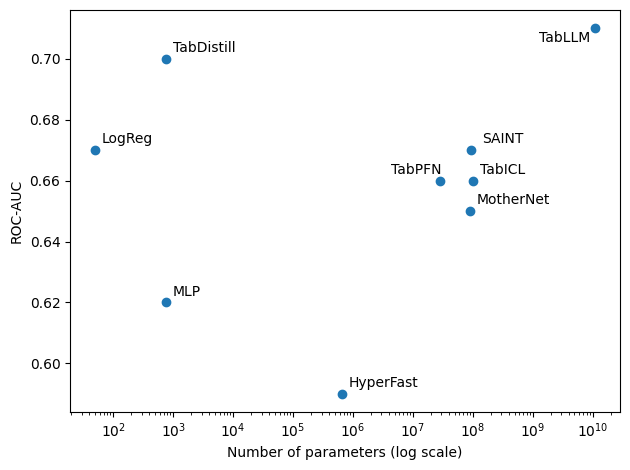

In [20]:
import matplotlib.pyplot as plt

# Input dimension
n = 50

models = list(auc.keys())
params = [n_params[m](n) for m in models]
scores = [auc[m] for m in models]

# Custom label offsets (dx, dy)
label_offsets = {
    'TabPFN': (-35, 5),
    'SAINT': (8, 5),
    'TabLLM': (-40, -10)
}

plt.figure()
plt.scatter(params, scores)

for m, x, y in zip(models, params, scores):
    dx, dy = label_offsets.get(m, (5, 5))
    plt.annotate(m, (x, y), textcoords="offset points", xytext=(dx, dy))

plt.xscale("log")
plt.xlabel("Number of parameters (log scale)")
plt.ylabel("ROC-AUC")
# plt.title(f"Average ROC-AUC vs Number of Parameters")
plt.tight_layout()
plt.show()